Goal: We want a firm-level ESG signal that is comparable across years and not dominated by boilerplate or individual token choices. Term counts and TF–IDF are sensitive to wording and disclosure templates. Embeddings give us a representation where two passages can be “close” even if they use different words.

Why AAPL 2015–2024: Before scaling to the whole S&P 500, we isolate one firm across a decade as a controlled test. This lets us sanity-check whether the embedding space is behaving sensibly: do years that “feel similar” read as similar, and do known changes in narrative correspond to shifts in embedding distance?

What we embed: Each report AAPL 2015 - 2024 becomes a document. We embed documents into vectors. To avoid long-section length artefacts, we chunk each section into fixed-size segments, embed each chunk, and take the mean vector. This makes the representation more stable than embedding the entire document in one pass.

What cosine similarity means here: Cosine similarity measures the angle between two embedding vectors. If two years’ sections are semantically similar, their vectors should point in similar directions (high cosine similarity). We then view a decade of filings as a time series in embedding space.

What we compute:

A cosine similarity matrix per section across years (10×10).

A distance-from-baseline curve: 1 − cosine_similarity(year, 2015) per section.

A single “firm narrative drift” series: average distance across sections.

Why this is relevant to ESG scoring: If ESG-related narrative changes are real (not just boilerplate), they should appear as directional changes in semantic space, not just as more occurrences of “emissions” or “diversity”. Embedding drift is therefore a candidate component of an ESG discourse signal, and it can be combined later with lexicon counts or sector-relative comparisons.

c:\Users\ddddd\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ddddd\AppData\Local\Temp\ipykernel_20588\1594177751.py:62: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  .agg(pl.col("text").str.concat("\n\n").alias("text"))
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 729.51it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect

ticker,year,n_chunks,cosine_similarity_to_base_year,cosine_distance_to_base_year
str,i64,i64,f64,f64
"""AAPL""",2015,25,1.0,5.9605e-8
"""AAPL""",2016,25,0.968196,0.031804
"""AAPL""",2017,25,0.977047,0.022953
"""AAPL""",2018,25,0.97273,0.02727
"""AAPL""",2019,20,0.937335,0.062665
"""AAPL""",2020,22,0.937329,0.062671
"""AAPL""",2021,24,0.931572,0.068428
"""AAPL""",2022,25,0.920123,0.079877
"""AAPL""",2023,24,0.922521,0.077479


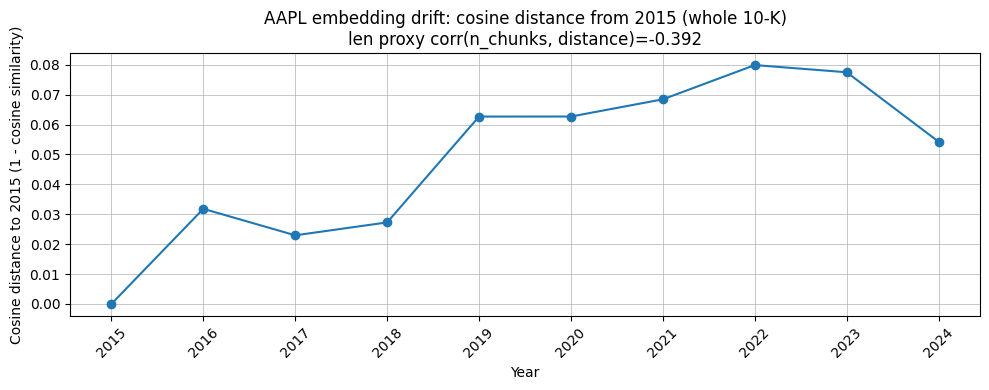

WindowsPath('embedding_outputs/05_aapl_2015_2024_cosine_distance_from_2015.png')

In [4]:
#  AAPL 2015–2024 (whole 10-K)
# What this cell does: load parquet -> build 1 doc per year -> chunk+embed -> cosine vs 2015 -> Polars DF -> plot + save PNG

from __future__ import annotations

from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer


PARQUET_FILE = "spy_10k_2015_present.parquet"
TICKER = "AAPL"
START_YEAR = 2015
END_YEAR = 2024
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

OUT_DIR = Path("embedding_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PNG_PATH = OUT_DIR / f"05_{TICKER.lower()}_{START_YEAR}_{END_YEAR}_cosine_distance_from_{START_YEAR}.png"


def safe_unlink(path: Path) -> None:
    # What this line does: delete existing PNG so reruns are reproducible
    if path.exists():
        path.unlink()

def chunk_text(text: str, max_chars: int = 3500) -> list[str]:
    # What this line does: stabilise embeddings by chunking long filings
    text = (text or "").strip()
    if not text:
        return []
    return [text[i:i+max_chars] for i in range(0, len(text), max_chars)]

def cosine_sim(u: np.ndarray, v: np.ndarray) -> float:
    # What this line does: cosine similarity between two vectors
    denom = (np.linalg.norm(u) * np.linalg.norm(v)) + 1e-12
    return float(np.dot(u, v) / denom)


df = pl.read_parquet(PARQUET_FILE).with_columns(
    pl.col("ticker").cast(pl.Utf8),
    pl.col("text").cast(pl.Utf8),
    pl.coalesce([pl.col("filing_period").cast(pl.Date), pl.col("filing_date").cast(pl.Date)]).alias("period_date"),
).with_columns(
    pl.col("period_date").dt.year().alias("year")
)

# What this line does: treat the whole 10-K as the unit of analysis (one doc per firm-year)
aapl_year_docs = (
    df
    .filter(
        (pl.col("ticker") == TICKER)
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
        & (pl.col("text").is_not_null())
        & (pl.col("text").str.len_chars() > 50)
    )
    .group_by(["ticker", "year"])
    .agg(pl.col("text").str.concat("\n\n").alias("text"))
    .sort(["year"])
)

years = aapl_year_docs["year"].to_list()
texts = aapl_year_docs["text"].to_list()

model = SentenceTransformer(MODEL_NAME)

embs = []
n_chunks = []
for t in texts:
    chunks = chunk_text(t, max_chars=3500)
    n_chunks.append(len(chunks))
    # What this line does: embed each chunk then mean-pool -> one stable embedding per year
    chunk_vecs = model.encode(chunks, normalize_embeddings=False, show_progress_bar=False) if chunks else np.zeros((0, 384))
    doc_vec = np.asarray(chunk_vecs, dtype=np.float32).mean(axis=0) if len(chunk_vecs) else np.zeros((384,), dtype=np.float32)
    embs.append(doc_vec)

baseline = embs[0]  # What this line does: baseline year is START_YEAR
cos_to_base = [cosine_sim(baseline, e) for e in embs]
dist_to_base = [1.0 - c for c in cos_to_base]

# What this line does: compact, interpretable Polars output table
out = pl.DataFrame({
    "ticker": [TICKER] * len(years),
    "year": years,
    "n_chunks": n_chunks,
    "cosine_similarity_to_base_year": cos_to_base,
    "cosine_distance_to_base_year": dist_to_base,
}).sort("year")

# What this line does: quick sanity check that “drift” isn’t just document length proxy
corr_len_vs_dist = float(np.corrcoef(np.asarray(n_chunks, dtype=float), np.asarray(dist_to_base, dtype=float))[0, 1])

display(out)

# What this line does: plot the time-series of embedding drift from baseline year
safe_unlink(PNG_PATH)
plt.figure(figsize=(10, 4))
plt.plot(out["year"].to_list(), out["cosine_distance_to_base_year"].to_list(), marker="o")
plt.title(f"{TICKER} embedding drift: cosine distance from {START_YEAR} (whole 10-K)\nlen proxy corr(n_chunks, distance)={corr_len_vs_dist:.3f}")
plt.xlabel("Year")
plt.ylabel(f"Cosine distance to {START_YEAR} (1 - cosine similarity)")
plt.xticks(out["year"].to_list(), rotation=45)
plt.grid(True, linewidth=0.5)
plt.tight_layout()
plt.savefig(PNG_PATH, dpi=200)
plt.show()

PNG_PATH


Figure above illustrates the cosine distance between Apple Inc.’s annual 10-K filings and the 2015 baseline, computed using whole-document embeddings. A pronounced increase in semantic distance is observed from 2019 onward, indicating a shift in the firm’s disclosure narrative that persists through subsequent years. Importantly, this divergence is not driven by document length, as evidenced by the negative correlation between embedding distance and a length proxy. The result suggests a genuine change in narrative structure rather than boilerplate expansion or verbosity effects.

# “Is AAPL’s disclosure narrative (embedding) unusually different from the rest of Information Technology in a given year, and how does that evolve 2015–2024?

Because the Information Technology sector is heterogeneous, global sector centroids can conflate narrative distinctiveness with sub-sector composition. We therefore score firms relative to a local semantic baseline using k-nearest neighbours in embedding space. This yields a sector-comparable measure of disclosure distinctiveness that is less sensitive to multi-modal sector structure and more robust to shared boilerplate.

C:\Users\ddddd\AppData\Local\Temp\ipykernel_20588\1483059653.py:74: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  .agg(pl.col(TEXT_COL).str.concat("\n\n").alias("text"))
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 792.47it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


firm_id,year,n_firms_year,k,n_chunks,mean_knn_cosine_similarity,min_knn_cosine_similarity,knn_distinctiveness,distinctiveness_percentile
str,i64,i64,i64,i64,f64,f64,f64,f64
"""AAPL""",2015,56,15,25,0.777699,0.767155,0.222301,0.909091
"""AAPL""",2016,59,15,25,0.809136,0.795624,0.190864,0.87931
"""AAPL""",2017,57,15,25,0.807363,0.794051,0.192637,0.875
"""AAPL""",2018,59,15,25,0.799573,0.781049,0.200427,0.896552
"""AAPL""",2019,62,15,20,0.837754,0.824494,0.162246,0.836066
"""AAPL""",2020,64,15,22,0.826938,0.813112,0.173062,0.857143
"""AAPL""",2021,67,15,24,0.835781,0.824293,0.164219,0.893939
"""AAPL""",2022,67,15,25,0.840058,0.825024,0.159942,0.893939
"""AAPL""",2023,68,15,24,0.842692,0.829284,0.157308,0.925373


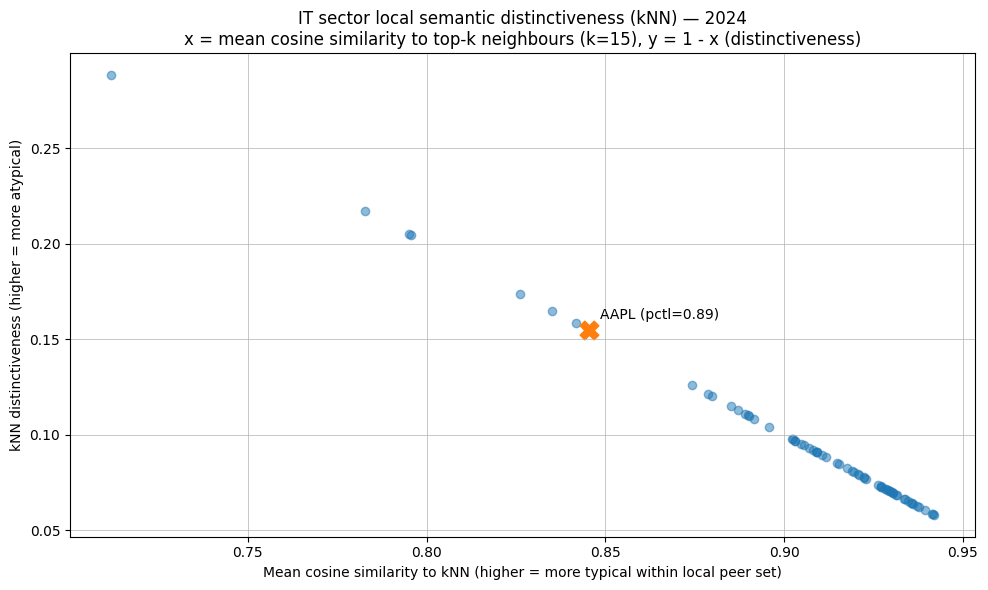

WindowsPath('embedding_outputs/05_it_knn_scatter_highlight_aapl_2015_2024.png')

In [6]:
# IT sector kNN distinctiveness scatter (whole 10-K embeddings)
# What this cell does: embed IT firm-years -> compute kNN similarity stats -> scatter all IT points -> highlight AAPL -> save PNG

from __future__ import annotations

from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer


PARQUET_FILE = "spy_10k_2015_present.parquet"
SECTOR_COL = "gics_sector"
SECTOR_VAL = "Information Technology"
FIRM_ID_COL = "ticker"               # switch to "cik" if you prefer
TEXT_COL = "text"

TICKER_HIGHLIGHT = "AAPL"
START_YEAR = 2015
END_YEAR = 2024

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
K = 15                               # kNN size (local baseline)
MAX_CHUNKS = 80                      # cap to reduce length artefacts; set None to disable
CHUNK_CHARS = 3500

OUT_DIR = Path("embedding_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PNG_PATH = OUT_DIR / f"05_it_knn_scatter_highlight_{TICKER_HIGHLIGHT.lower()}_{START_YEAR}_{END_YEAR}.png"


def safe_unlink(path: Path) -> None:
    # What this line does: delete existing PNG so reruns are reproducible
    if path.exists():
        path.unlink()

def chunk_text(text: str, max_chars: int = 3500) -> list[str]:
    # What this line does: chunk long filings for stable mean-pooled embeddings
    text = (text or "").strip()
    if not text:
        return []
    return [text[i:i+max_chars] for i in range(0, len(text), max_chars)]

def cosine_sim_matrix(X: np.ndarray) -> np.ndarray:
    # What this line does: cosine similarity matrix for row vectors
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    Xn = X / norms
    return Xn @ Xn.T


df = pl.read_parquet(PARQUET_FILE).with_columns(
    pl.col(FIRM_ID_COL).cast(pl.Utf8),
    pl.col(SECTOR_COL).cast(pl.Utf8),
    pl.col(TEXT_COL).cast(pl.Utf8),
    pl.coalesce([pl.col("filing_period").cast(pl.Date), pl.col("filing_date").cast(pl.Date)]).alias("period_date"),
).with_columns(
    pl.col("period_date").dt.year().alias("year")
)

it_docs = (
    df
    .filter(
        (pl.col(SECTOR_COL) == SECTOR_VAL)
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
        & (pl.col(TEXT_COL).is_not_null())
        & (pl.col(TEXT_COL).str.len_chars() > 50)
        & (pl.col(FIRM_ID_COL).is_not_null())
    )
    # What this line does: one whole-10K doc per firm-year
    .group_by([FIRM_ID_COL, "year"])
    .agg(pl.col(TEXT_COL).str.concat("\n\n").alias("text"))
    .sort(["year", FIRM_ID_COL])
)

model = SentenceTransformer(MODEL_NAME)

# What this line does: embed each firm-year document (chunk -> encode -> mean pool)
rows = []
for r in it_docs.iter_rows(named=True):
    chunks = chunk_text(r["text"], max_chars=CHUNK_CHARS)
    if MAX_CHUNKS is not None and len(chunks) > MAX_CHUNKS:
        chunks = chunks[:MAX_CHUNKS]  # What this line does: cap chunks to reduce length-driven variance

    if chunks:
        vecs = model.encode(chunks, normalize_embeddings=False, show_progress_bar=False)
        emb = np.asarray(vecs, dtype=np.float32).mean(axis=0)
    else:
        emb = np.zeros((384,), dtype=np.float32)

    rows.append({
        "firm_id": r[FIRM_ID_COL],
        "year": int(r["year"]),
        "n_chunks": int(len(chunks)),
        "embedding": emb,
    })

# What this line does: compute kNN stats year-by-year (local semantic baseline)
out_rows = []
for y in range(START_YEAR, END_YEAR + 1):
    yr = [x for x in rows if x["year"] == y]
    if len(yr) < 3:
        continue

    X = np.stack([x["embedding"] for x in yr], axis=0)
    S = cosine_sim_matrix(X)  # cosine similarities, diag = 1

    k_eff = min(K, len(yr) - 1)

    for i, x in enumerate(yr):
        sims = S[i].copy()
        sims[i] = -np.inf  # What this line does: exclude self from neighbours
        nn_idx = np.argpartition(-sims, k_eff)[:k_eff]  # top-k by cosine similarity
        nn_sims = sims[nn_idx]

        mean_knn_sim = float(np.mean(nn_sims))
        min_knn_sim = float(np.min(nn_sims))
        # What this line does: distinctiveness = 1 - mean similarity to nearest neighbours
        knn_distinctiveness = 1.0 - mean_knn_sim

        out_rows.append({
            "firm_id": x["firm_id"],
            "year": x["year"],
            "n_firms_year": len(yr),
            "k": k_eff,
            "n_chunks": x["n_chunks"],
            "mean_knn_cosine_similarity": mean_knn_sim,
            "min_knn_cosine_similarity": min_knn_sim,
            "knn_distinctiveness": knn_distinctiveness,
        })

out = pl.DataFrame(out_rows)

# What this line does: compute within-year percentile for AAPL (higher percentile = more distinctive)
out = out.with_columns(
    pl.col("knn_distinctiveness")
    .rank(method="average")
    .over("year")
    .alias("rank_distinctiveness")
).with_columns(
    ((pl.col("rank_distinctiveness") - 1) / (pl.col("n_firms_year") - 1)).alias("distinctiveness_percentile")
).drop("rank_distinctiveness")

display(out.filter(pl.col("firm_id") == TICKER_HIGHLIGHT).sort("year"))

# --------------------
# Scatter plot (all IT points; highlight AAPL)
# --------------------
safe_unlink(PNG_PATH)

# What this line does: pick one year to visualise as a scatter; use latest year by default
YEAR_FOR_SCATTER = END_YEAR

scatter_df = out.filter(pl.col("year") == YEAR_FOR_SCATTER).select([
    "firm_id",
    "year",
    "mean_knn_cosine_similarity",
    "knn_distinctiveness",
    "distinctiveness_percentile",
])

x = scatter_df["mean_knn_cosine_similarity"].to_numpy()
y = scatter_df["knn_distinctiveness"].to_numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)

aapl_row = scatter_df.filter(pl.col("firm_id") == TICKER_HIGHLIGHT)
if aapl_row.height == 1:
    ax = float(aapl_row["mean_knn_cosine_similarity"][0])
    ay = float(aapl_row["knn_distinctiveness"][0])
    ap = float(aapl_row["distinctiveness_percentile"][0])
    plt.scatter([ax], [ay], s=180, marker="X")
    plt.annotate(f"{TICKER_HIGHLIGHT} (pctl={ap:.2f})", (ax, ay), textcoords="offset points", xytext=(8, 8))

plt.title(
    f"IT sector local semantic distinctiveness (kNN) — {YEAR_FOR_SCATTER}\n"
    f"x = mean cosine similarity to top-k neighbours (k={min(K, scatter_df.height-1)}), "
    f"y = 1 - x (distinctiveness)"
)
plt.xlabel("Mean cosine similarity to kNN (higher = more typical within local peer set)")
plt.ylabel("kNN distinctiveness (higher = more atypical)")
plt.grid(True, linewidth=0.5)
plt.tight_layout()
plt.savefig(PNG_PATH, dpi=200)
plt.show()

PNG_PATH


Most of the code covered in this section is highly resource intensive. It is advised to use cloud computing as a means to reproduce it. { TODO: Import it from Google Colab }

In [3]:
uv pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


Using Python 3.13.7 environment at: c:\Users\ddddd\AppData\Local\Programs\Python\Python313
Audited 1 package in 2m 28s
